## ANÁLISIS EXPLORATORIO DE DATOS 
### HACIENDO CIENCIA 2026
Análisis de NVIDIA Y Alphabet

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import yfinance as yf

- Open = precio apertura
- High = máximo del día
- Low = mínimo del día
- Close = cierre
- Volume = volumen operado

In [25]:
nvda = yf.download("NVDA",period="3y")
googl = yf.download("GOOGL", period="3y")
tickers = pd.concat([nvda, googl], axis=1, keys=["NVDA","GOOGL"])


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [26]:
tickers.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 753 entries, 2023-06-27 to 2026-06-26
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   (NVDA, Close, NVDA)     753 non-null    float64
 1   (NVDA, High, NVDA)      753 non-null    float64
 2   (NVDA, Low, NVDA)       753 non-null    float64
 3   (NVDA, Open, NVDA)      753 non-null    float64
 4   (NVDA, Volume, NVDA)    753 non-null    int64  
 5   (GOOGL, Close, GOOGL)   753 non-null    float64
 6   (GOOGL, High, GOOGL)    753 non-null    float64
 7   (GOOGL, Low, GOOGL)     753 non-null    float64
 8   (GOOGL, Open, GOOGL)    753 non-null    float64
 9   (GOOGL, Volume, GOOGL)  753 non-null    int64  
dtypes: float64(8), int64(2)
memory usage: 64.7 KB


In [27]:
tickers.isnull().sum()

       Price   Ticker
NVDA   Close   NVDA      0
       High    NVDA      0
       Low     NVDA      0
       Open    NVDA      0
       Volume  NVDA      0
GOOGL  Close   GOOGL     0
       High    GOOGL     0
       Low     GOOGL     0
       Open    GOOGL     0
       Volume  GOOGL     0
dtype: int64

In [28]:
tickers.duplicated().sum()

np.int64(0)

In [29]:
tickers = tickers.dropna()
tickers = tickers.sort_index(ascending=False)
tickers

NVDA                                                 \
Price            Close        High         Low        Open     Volume   
Ticker            NVDA        NVDA        NVDA        NVDA       NVDA   
Date                                                                    
2026-06-26  192.529999  195.550003  191.220001  193.119995  178906300   
2026-06-25  195.740005  200.800003  192.130005  200.080002  149550000   
2026-06-24  199.000000  201.669998  196.580002  200.119995  151810700   
2026-06-23  200.039993  203.770004  200.000000  202.169998  153496200   
2026-06-22  208.649994  213.990005  207.720001  211.440002  122041400   
...                ...         ...         ...         ...        ...   
2023-07-03   42.330524   42.814582   42.119936   42.434322  198209000   
2023-06-30   42.219753   42.467272   41.420312   41.598965  501148000   
2023-06-29   40.742634   41.519121   40.521065   41.477203  380514000   
2023-06-28   41.037056   41.763641   40.439222   40.580944  582639000   
2023-06-27   41.794579   41.858453   40.369357   40.719673  462175000   

                 GOOGL                                                 
Price            Close        High         Low        Open     Volume  
Ticker           GOOGL       GOOGL       GOOGL       GOOGL      GOOGL  
Date                                                                   
2026-06-26  337.390015  346.359985  330.200012  342.549988  114642600  
2026-06-25  343.709991  345.570007  335.839996  336.730011   44491400  
2026-06-24  345.290009  353.480011  341.929993  349.040009   44997300  
2026-06-23  346.130005  349.290009  340.200012  340.690002   34007700  
2026-06-22  349.679993  358.920013  341.720001  357.950012   52814800  
...                ...         ...         ...         ...        ...  
2023-07-03  118.846161  119.133613  117.775652  118.191958   14467900  
2023-06-30  118.647919  120.015794  118.638012  119.113789   29532200  
2023-06-29  118.053200  119.004761  117.260236  118.191969   24090900  
2023-06-28  119.123711  119.331864  115.822977  116.060865   27091400  
2023-06-27  117.289970  118.033378  115.079567  116.050957   39535900  

[753 rows x 10 columns]

In [30]:
print("Fecha inicio" , tickers.index.min())
print("Fecha corte" , tickers.index.max())
print("Total de dias", len(tickers))

Fecha inicio 2023-06-27 00:00:00
Fecha corte 2026-06-26 00:00:00
Total de dias 753


In [31]:
# Precios no negativos 
(tickers <=0).sum()

       Price   Ticker
NVDA   Close   NVDA      0
       High    NVDA      0
       Low     NVDA      0
       Open    NVDA      0
       Volume  NVDA      0
GOOGL  Close   GOOGL     0
       High    GOOGL     0
       Low     GOOGL     0
       Open    GOOGL     0
       Volume  GOOGL     0
dtype: int64

In [32]:
tickers.describe()

NVDA                                                    \
Price        Close        High         Low        Open        Volume   
Ticker        NVDA        NVDA        NVDA        NVDA          NVDA   
count   753.000000  753.000000  753.000000  753.000000  7.530000e+02   
mean    126.119784  128.173072  123.932648  126.187234  3.059888e+08   
std      53.079661   53.798764   52.435811   53.198214  1.639562e+08   
min      40.250908   40.802882   39.156950   40.374680  6.552850e+07   
25%      86.888649   88.621641   85.118698   86.779826  1.789024e+08   
50%     129.027344  131.043996  126.670807  129.356790  2.513811e+08   
75%     177.593491  179.660693  174.816766  177.053641  3.996780e+08   
max     235.465576  236.264633  229.033071  229.602402  1.156044e+09   

             GOOGL                                                    
Price        Close        High         Low        Open        Volume  
Ticker       GOOGL       GOOGL       GOOGL       GOOGL         GOOGL  
count   753.000000  753.000000  753.000000  753.000000  7.530000e+02  
mean    200.815725  203.013112  198.376375  200.636056  3.148844e+07  
std      74.042000   74.950188   72.850294   73.919356  1.379141e+07  
min     115.426476  116.675410  114.336152  115.267893  1.009740e+07  
25%     148.750992  150.540250  146.585468  148.622130  2.290200e+07  
50%     171.454437  173.679941  169.916728  171.914421  2.803970e+07  
75%     244.970688  246.328013  241.826826  244.182227  3.537630e+07  
max     402.379669  408.366081  396.123378  399.681282  1.274901e+08

La tabla anterior muestra las estadísticas descriptivas de los precios 
históricos de NVDA y GOOGL durante los 3 años analizados (~753 días hábiles).
NVDA presenta mayor rango de precios (de $40 a $235) comparado con GOOGL 
(de $115 a $402), reflejando su mayor volatilidad histórica.

### Gráficas de precios historia

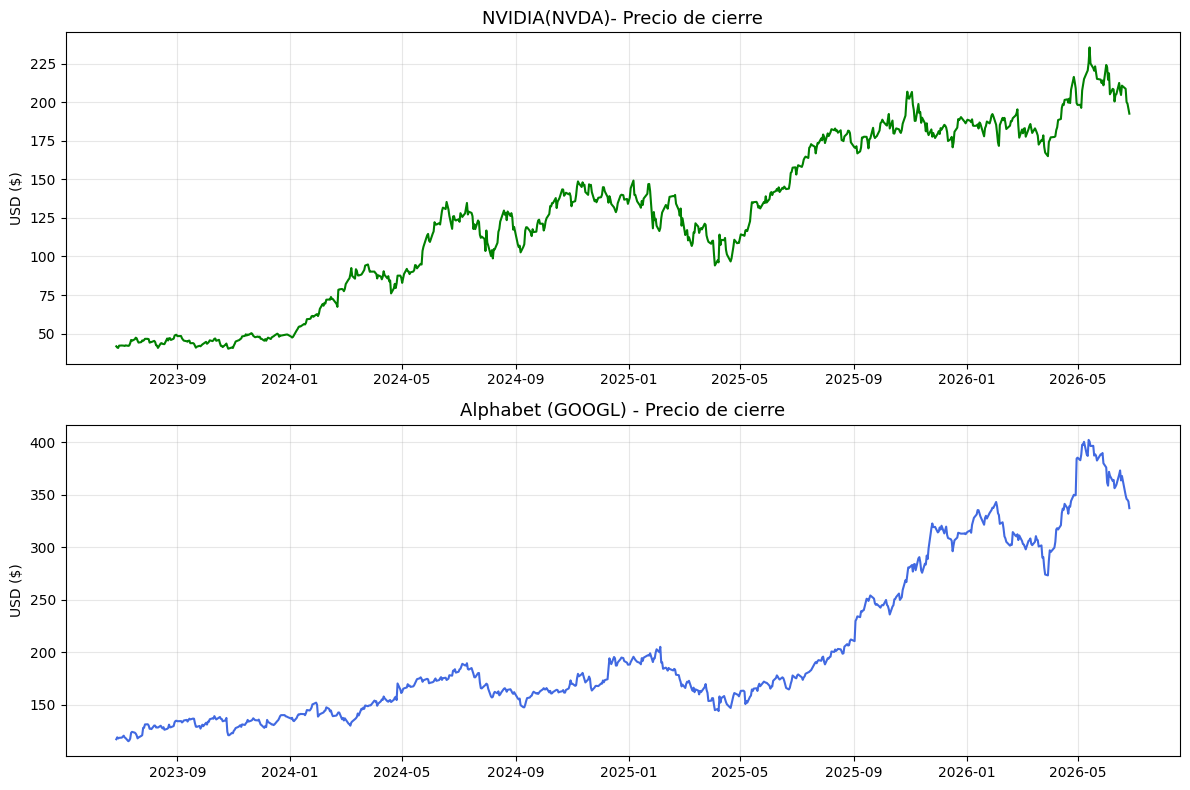

In [33]:
fig, axes = plt.subplots(2, 1, figsize=(12,8))
# Nivida
axes[0].plot(tickers["NVDA"]["Close"], color="green", linewidth=1.5)
axes[0].set_title("NVIDIA(NVDA)- Precio de cierre", fontsize=13)
axes[0].set_ylabel("USD ($)")
axes[0].grid(True, alpha=0.3)
#Google
axes[1].plot(tickers["GOOGL"]["Close"], color="royalblue", linewidth=1.5)
axes[1].set_title("Alphabet (GOOGL) - Precio de cierre", fontsize=13)
axes[1].set_ylabel("USD ($)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("precios_historicos.png", dpi=150)
plt.show()

NVIDIA comenzó el período en mayo de 2023 con un precio de aproximadamente $28 USD. A partir de mediados de 2023 se observa un crecimiento acelerado y sostenido, impulsado principalmente por la demanda de GPUs para inteligencia artificial. El precio alcanzó máximos cercanos a $205 USD a principios de 2025.

Alphabet inició el período en aproximadamente $120 USD. Su comportamiento fue relativamente estable durante 2023, con un crecimiento moderado. A partir de mediados de 2024 se aprecia una tendencia alcista más pronunciada, cerrando el período cerca de los $400 USD

## Cálculo de rendimiento 

In [34]:
precios = tickers.xs("Close", axis=1, level="Price")
precios = precios.sort_index(ascending=True)
precios.columns = ["NVDA", "GOOGL"]
precios

,NVDA,GOOGL
Date,,
2023-06-27,41.794579,117.289970
2023-06-28,41.037056,119.123711
2023-06-29,40.742634,118.053200
2023-06-30,42.219753,118.647919
2023-07-03,42.330524,118.846161
...,...,...
2026-06-22,208.649994,349.679993
2026-06-23,200.039993,346.130005
2026-06-24,199.000000,345.290009


In [35]:
# Ri = ln(S_i/ S_i-1 )
rendimientos = np.log(precios / precios.shift(1))
rendimientos = rendimientos.dropna()

print("Dias con rendimiento", len(rendimientos))
rendimientos

Dias con rendimiento 752


,NVDA,GOOGL
Date,,
2023-06-28,-0.018291,0.015513
2023-06-29,-0.007200,-0.009027
2023-06-30,0.035613,0.005025
2023-07-03,0.002620,0.001669
2023-07-05,-0.002266,0.015312
...,...,...
2026-06-22,-0.009730,-0.051146
2026-06-23,-0.042141,-0.010204
2026-06-24,-0.005212,-0.002430


In [36]:
rendimientos.describe().T

,count,mean,std,min,25%,50%,75%,max
NVDA,752.0,0.002031,0.029477,-0.185946,-0.013896,0.002700,0.018550,0.171621
GOOGL,752.0,0.001405,0.018742,-0.099924,-0.008967,0.002173,0.011285,0.097348


NVIDIA sigue volátil y de riesgo, mientras GOOGLE es mas estable

NVDIA ±3.045 volátil

GOOGLE ±1.854 volátil

## valores S = (S_1,S_2,..., S_20)

In [37]:
# S=(S1, S2,....,S20)

precios_semanal = precios.resample("W-Fri").last()
precios_20 = precios_semanal.tail(21)

print("Últimas 20 semanas")
print(f"Desde: {precios_20.index[0].date()}")
print(f"Hasta: {precios_20.index[-1].date()}")
print()

# 20 rendimientos
rendimientos_20 = np.log(precios_20 / precios_20.shift(1)).dropna()

print(f"Semana con rendimiento: {len(rendimientos_20)}")
print()
rendimientos_20 = rendimientos_20.sort_index(ascending=False)
rendimientos_20.T

Últimas 20 semanas
Desde: 2026-02-06
Hasta: 2026-06-26

Semana con rendimiento: 20



Date,2026-06-26,2026-06-19,2026-06-12,2026-06-05,2026-05-29,2026-05-22,2026-05-15,2026-05-08,2026-05-01,2026-04-24,2026-04-17,2026-04-10,2026-04-03,2026-03-27,2026-03-20,2026-03-13,2026-03-06,2026-02-27,2026-02-20,2026-02-13
NVDA,-0.090136,0.026451,0.000439,-0.027859,-0.019650,-0.045350,0.045954,0.081031,-0.048298,0.032153,0.066895,0.061437,0.057248,-0.030453,-0.042789,0.013627,0.003549,-0.068854,0.037629,-0.014122
GOOGL,-0.086925,0.022950,-0.023710,-0.031543,-0.006891,-0.035425,-0.010081,0.038429,0.113230,0.007929,0.074216,0.070076,0.075214,-0.092742,-0.004243,0.013220,-0.043397,-0.010276,0.029840,-0.054549


In [38]:
rendimientos_20.describe().T

,count,mean,std,min,25%,50%,75%,max
NVDA,20.0,0.001945,0.048586,-0.090136,-0.033537,0.001994,0.039710,0.081031
GOOGL,20.0,0.002266,0.054302,-0.092742,-0.032514,-0.005567,0.031987,0.113230


Durante las últimas 20 semanas hábiles, ambas empresas mostraron
rendimientos promedio semanales positivos: NVDA con +0.52% y GOOGL
con +0.73%. En términos de volatilidad, ambas presentan ±2.4% semanal.
NVDA registró su peor semana en -4.74% y su mejor en +5.61%, mientras
GOOGL tuvo una caída máxima de -3.08% y una subida de +9.50%.

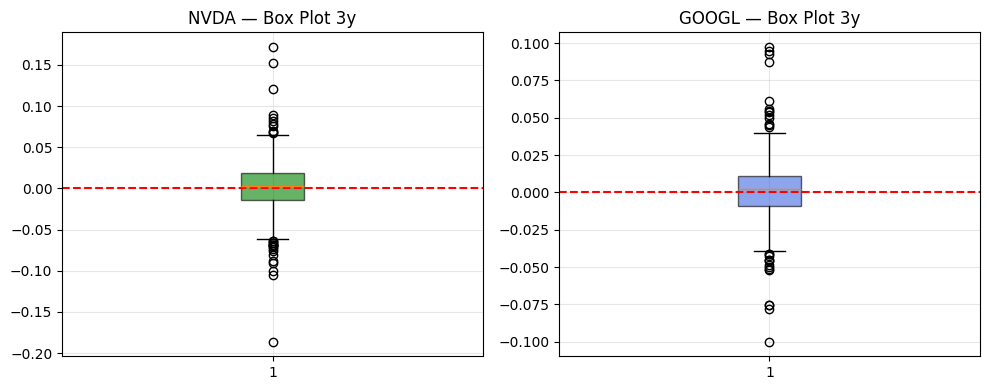

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, ticker, color in zip(axes, ["NVDA", "GOOGL"], ["green", "royalblue"]):
    ax.boxplot(rendimientos[ticker], patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6))
    ax.axhline(0, color="red", linestyle="--")
    ax.set_title(f"{ticker} — Box Plot 3y", fontsize=12)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("boxplot_3y.png", dpi=150)
plt.show()

En los 3 años de datos diarios, NVDA muestra movimientos entre -2% y +2%
la mayoría de días, con algunos valores extremos. GOOGL tiene una caja
más compacta pero con un outlier notable en su extremo superior.

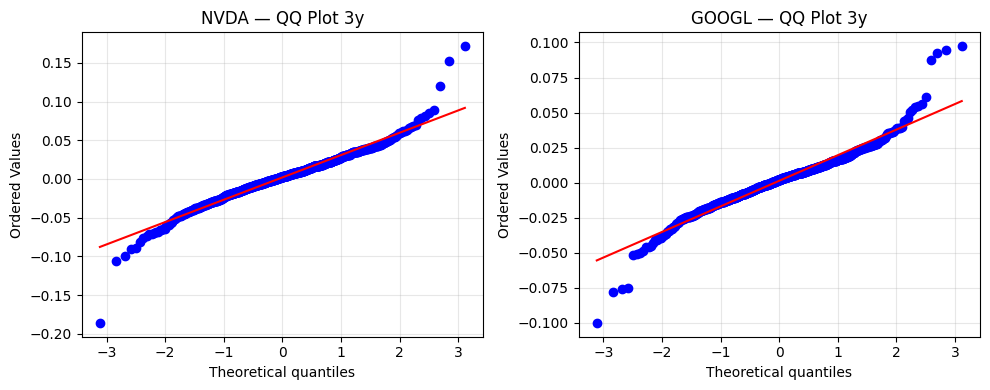

In [40]:
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, ticker, color in zip(axes, ["NVDA", "GOOGL"], ["green", "royalblue"]):
    stats.probplot(rendimientos[ticker], dist="norm", plot=ax)
    ax.set_title(f"{ticker} — QQ Plot 3y", fontsize=12)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("qqplot_3y.png", dpi=150)
plt.show()

En el período de 3 años, NVDA se separa de la línea teórica en las colas,
confirmando que sus rendimientos tienen más eventos extremos de lo que
una normal predice. GOOGL muestra un comportamiento similar, con mayor
desviación en el extremo superior.

## Skewness y Kurtosis

In [41]:
from scipy import stats

print("Skewness (3y):")
print(rendimientos.skew().round(6))

print("\nKurtosis (3y):")
print(rendimientos.kurt().round(6))


# Para los últimos días habiles
print("\nSkewness últimos 20 semanas:")
print(rendimientos_20.skew().round(6))

print("\nKurtosis últimos 20 semanas:")
print(rendimientos_20.kurt().round(6))


Skewness (3y):
NVDA    -0.080637
GOOGL    0.101595
dtype: float64

Kurtosis (3y):
NVDA     4.794091
GOOGL    4.743222
dtype: float64

Skewness últimos 20 semanas:
NVDA    -0.106864
GOOGL    0.203434
dtype: float64

Kurtosis últimos 20 semanas:
NVDA    -0.947095
GOOGL   -0.268174
dtype: float64


Los rendimientos de NVDA y GOOGL no siguen una distribución normal,
tienen colas más pesadas de lo esperado — especialmente NVDA.
En las últimas 20 semanas, GOOGL aparenta ser más volátil de lo normal,
pero es por una sola semana atípica de +9.5% que distorsiona todo.

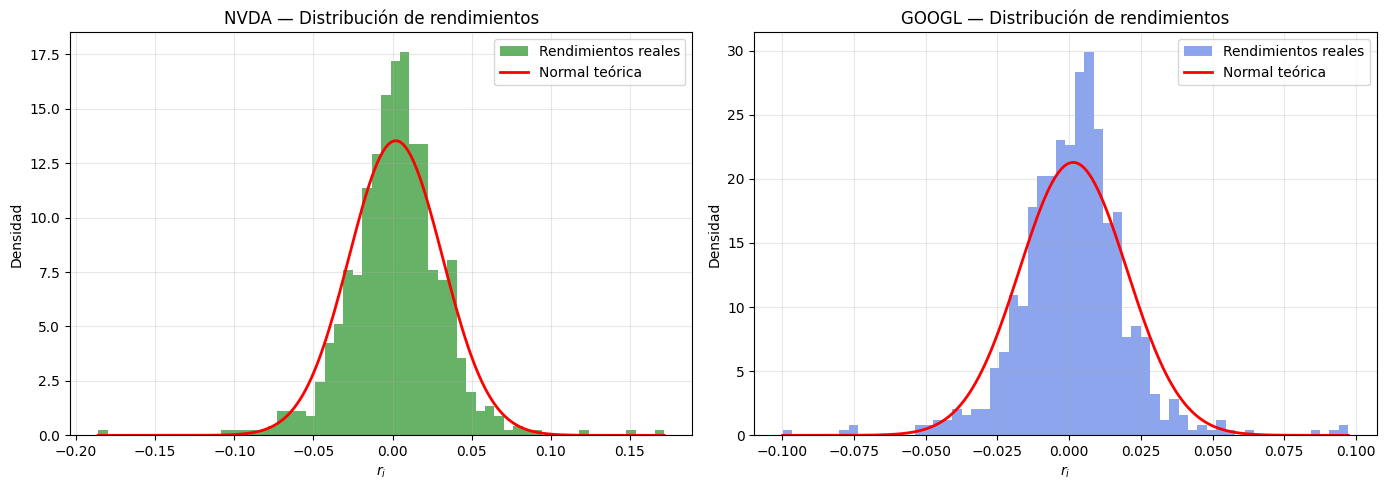

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, ticker, color in zip(axes, ["NVDA", "GOOGL"], ["green", "royalblue"]):    
    datos_r = rendimientos[ticker]
    # Histograma de rendimientos reales
    ax.hist(datos_r, bins=60, density=True, 
            color=color, alpha=0.6, label="Rendimientos reales")
    
    mu    = datos_r.mean()
    sigma = datos_r.std()
    x     = np.linspace(datos_r.min(), datos_r.max(), 200)
    normal_teorica = stats.norm.pdf(x, mu, sigma)
    
    ax.plot(x, normal_teorica, color="red", linewidth=2, label="Normal teórica")
    ax.set_title(f"{ticker} — Distribución de rendimientos", fontsize=12)
    ax.set_xlabel("$r_i$")
    ax.set_ylabel("Densidad")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("histograma_rendimientos.png", dpi=150)
plt.show()

La curva roja nunca logra ajustarse bien a los datos reales, el centro es demasiado bajo y las colas demasiado cortas. Esto confirma que los rendimientos financieros no son normales.

## Matriz de correlación

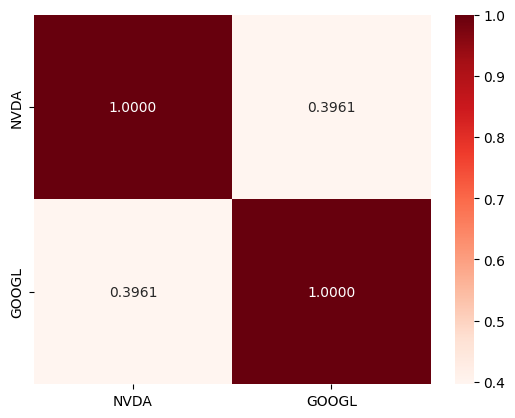

In [43]:
correlacion= rendimientos.corr()
correlacion.round(4)

sns.heatmap(correlacion,cmap="Reds",fmt = ".4f", annot=True)
plt.show()

NVDA y GOOGL tienen una correlación de 0.39 — positiva y moderada. Cuando el mercado tecnológico sube, ambas tienden a subir juntas(comparten dirección).

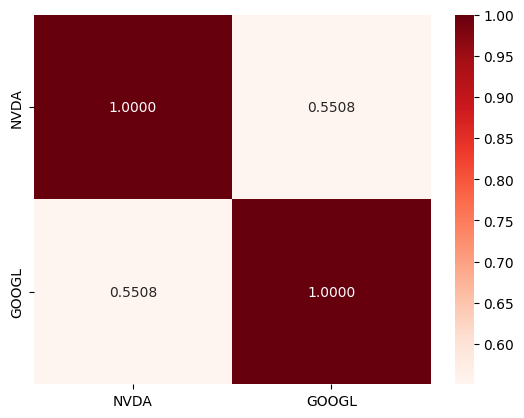

In [44]:
correlacion_20 =rendimientos_20.corr()
sns.heatmap(correlacion_20,cmap="Reds", fmt=".4f", annot=True)
plt.show()


En las últimas 20 semanas la correlación cambia, lo que sugiere que en períodos cortos la relación entre ambaspuede variar significativamente.

CSV

In [45]:
rendimientos.to_csv("rendimientos_diarios3y.csv")